In [1]:
%load_ext autoreload
%autoreload 2
from autogluon.timeseries import TimeSeriesDataFrame
import pandas as pd
import numpy as np
from pathlib import Path
from src.data.preprocessor import read_smard_data

# Read data

In [17]:
import numpy as np
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame

# Parameters
n_points = 2000
n_series = 3  # number of different time series
dates = pd.date_range("2024-01-01", periods=n_points, freq="D")

# Create sinusoidal patterns with noise for multiple series
dfs = []
for i in range(n_series):
    # different frequency & phase for each series
    freq = 0.1 + 0.05 * i
    phase = np.pi / 4 * i
    noise = np.random.normal(0, 0.7, size=n_points)

    values = np.sin(np.arange(n_points) * freq + phase) + noise

    df = pd.DataFrame({
        "item_id": i,
        "timestamp": dates,
        "target": values
    })
    dfs.append(df)

# Combine and convert to TimeSeriesDataFrame
data = TimeSeriesDataFrame.from_data_frame(pd.concat(dfs, ignore_index=True))

print(data.head(15))


                      target
item_id timestamp           
0       2024-01-01  0.225285
        2024-01-02 -0.447117
        2024-01-03  0.682619
        2024-01-04 -0.117733
        2024-01-05  0.914107
        2024-01-06  0.287548
        2024-01-07 -0.640091
        2024-01-08 -0.043474
        2024-01-09  0.416066
        2024-01-10  1.741059
        2024-01-11  1.472272
        2024-01-12  2.027910
        2024-01-13  2.089584
        2024-01-14  0.589233
        2024-01-15  0.853509


# Predictions

In [3]:
# set frequency and quantiles
lead_times = np.arange(1, 192+1).tolist()
quantiles = np.arange(0.1,1,0.1).round(1).tolist()
freq = pd.DateOffset(minutes=15)

## Minimum working example

In [4]:
from src.postprocessors.mle import PostprocessorMLE
from src.postprocessors.qr import PostprocessorFastQR
from src.postprocessors.eqc import PostprocessorEQC
from src.pipeline.pipeline import ForecastingPipeline
from src.predictors.chronos import Chronos

2025-09-30 17:42:12,465 - INFO - config.py - PyTorch version 2.5.1 available.


In [ ]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "mps",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
    },
    freq="D",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 17:42:16,800 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 17:42:16,801 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 17:42:16,801 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

2025-09-30 17:42:23,657 - INFO - chronos.py - Using default schedule because head is resized.
2025-09-30 17:42:23,660 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → last_layer → full
2025-09-30 17:42:23,661 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/LinQC
2025-09-30 17:42:23,661 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/ConQC


In [18]:
forecasts = pipeline.generate_forecasts(data, rolling=False)

2025-09-30 17:49:41,408 - INFO - pipeline.py - Starting forecast generation of model Chronos-Bolt-tiny for data_test from 2024-01-01 00:00:00 to 2029-06-22 00:00:00


Predicting using Chronos:   0%|          | 0/1 [00:00<?, ?it/s]

2025-09-30 17:50:14,397 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:14,477 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:17,146 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:17,611 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:17,620 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:17,753 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:18,141 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:50:18,349 - INFO - config.py - PyTorch version 2.5.1 available.
/Users/louis.skowronek/Documents/Projects/mt-probabilistic-forecasting-framework/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
2025-09-30 17:50:29,610 - INFO - base.py - Chronos: Time to generate forec

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/opt/homebrew/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/opt/homebrew/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/opt/homebrew/Cellar/python@3.12/3.12.7_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/

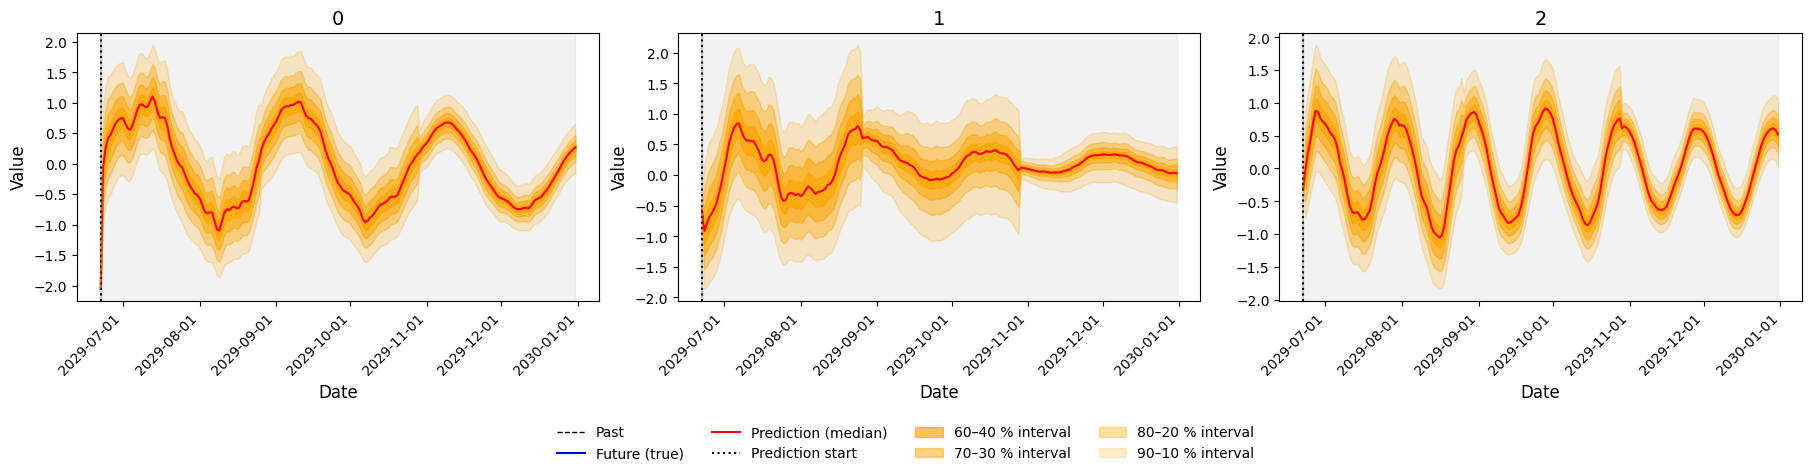

In [19]:
forecasts["Chronos-Bolt-tiny"].plot_forecasts()

In [ ]:
# or convert to autogluon
forecasts["Chronos-Bolt-tiny"].to_AutogluonFormat().head()

mean           0.1           0.2   
item_id timestamp                                                       
0       2025-09-01 00:15:00  10305.457031  10008.364258  10101.958984  \
        2025-09-01 00:30:00  10259.710938   9980.574219  10072.022461   
        2025-09-01 00:45:00  10171.929688   9902.679688   9995.127930   
        2025-09-01 01:00:00  10092.146484   9825.907227   9917.337891   
        2025-09-01 01:15:00  10026.693359   9776.124023   9853.818359   

                                      0.3           0.4           0.5   
item_id timestamp                                                       
0       2025-09-01 00:15:00  10173.560547  10235.219727  10305.457031  \
        2025-09-01 00:30:00  10139.001953  10199.998047  10259.710938   
        2025-09-01 00:45:00  10053.735352  10104.611328  10171.929688   
        2025-09-01 01:00:00   9978.470703  10034.669922  10092.146484   
        2025-09-01 01:15:00   9917.074219   9972.816406  10026.693359   

                                      0.6           0.7           0.8   
item_id timestamp                                                       
0       2025-09-01 00:15:00  10378.813477  10453.540039  10558.461914  \
        2025-09-01 00:30:00  10335.916016  10412.776367  10508.651367   
        2025-09-01 00:45:00  10229.861328  10305.671875  10393.163086   
        2025-09-01 01:00:00  10148.395508  10216.103516  10294.623047   
        2025-09-01 01:15:00  10090.862305  10150.933594  10220.537109   

                                      0.9  
item_id timestamp                          
0       2025-09-01 00:15:00  10702.966797  
        2025-09-01 00:30:00  10641.357422  
        2025-09-01 00:45:00  10518.078125  
        2025-09-01 01:00:00  10401.531250  
        2025-09-01 01:15:00  10325.245117

# Fine tune Chronos on extended prediction length

In [21]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "mps",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
        "finetuning_schedule": ["Full"],
        "finetuning_adjust_pretrained_prediction_length": True,
        "finetuning_warmup_new_neurons": True,
    },
    postprocessors=[PostprocessorFastQR, PostprocessorEQC],
    postprocessor_kwargs=[{"name": "LinQC", "n_jobs": 4}, {"name": "ConQC","n_jobs": 4}],
    freq="D",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 17:52:43,579 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 17:52:43,580 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 17:52:43,581 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-30 17:52:45,134 - INFO - chronos.py - Prepended 'new_neurons' for warm-up of new output rows.
2025-09-30 17:52:45,144 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → full
2025-09-30 17:52:45,145 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/LinQC
2025-09-30 17:52:45,148 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/ConQC


In [ ]:
# just select a subset for training
data_train = data.slice_by_timestep(end_index=-500)
data_val = data.slice_by_timestep(start_index=-1000, end_index=-500)

In [ ]:
pipeline.train_predictor_model(data_train=data, max_val_windows = 3, train_window_step=1)

2025-09-30 17:59:07,220 - INFO - pipeline.py - Initializing predictor with model: Chronos
2025-09-30 17:59:07,221 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 17:59:07,221 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 17:59:07,222 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-30 17:59:08,581 - INFO - chronos.py - Prepended 'new_neurons' for warm-up of new output rows.
2025-09-30 17:59:08,587 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → full
2025-09-30 17:59:08,591 - INFO - pipeline.py - Auto-generating validation data from training data...
2025-09-30 17:59:08,591 - INFO - pipeline.py - Auto-validation using val_window_step=192
2025-09-30 17:59:08,592 - INFO - pipeline.py - Automatically splitting data into training and validation data...
2025-09-30 17:59:08,603 - INFO - pip

{'eval_loss': 129.38528442382812, 'eval_runtime': 23.8658, 'eval_samples_per_second': 0.377, 'eval_steps_per_second': 0.042, 'epoch': 0}


2025-09-30 17:59:52,395 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:59:52,396 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:59:52,396 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 17:59:52,398 - INFO - config.py - PyTorch version 2.5.1 available.
Could not estimate the number of tokens of the input, floating-point operations will not be computed


{'loss': 116.2453, 'grad_norm': 12.306472778320312, 'learning_rate': 9.90625e-05, 'epoch': 0.25}
{'loss': 114.0553, 'grad_norm': 10.556512832641602, 'learning_rate': 9.781250000000001e-05, 'epoch': 0.5}


2025-09-30 18:00:18,585 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:00:18,585 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:00:18,585 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:00:18,585 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:00:25,660 - INFO - chronos.py - New best @ step 8: eval_loss=124.4917, marking .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny/stage_0_new_neurons/training/checkpoint-8


...

2025-09-30 18:18:42,303 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:18:42,303 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:18:42,303 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:18:42,867 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:18:50,788 - INFO - chronos.py - New best @ step 144: eval_loss=99.5399, marking .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny/stage_0_new_neurons/training/checkpoint-144


{'eval_loss': 99.53990173339844, 'eval_runtime': 34.5258, 'eval_samples_per_second': 0.261, 'eval_steps_per_second': 0.029, 'epoch': 9.0}


2025-09-30 18:19:10,876 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:19:10,876 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:19:10,876 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:19:10,876 - INFO - config.py - PyTorch version 2.5.1 available.


{'loss': 95.2097, 'grad_norm': 4.83288049697876, 'learning_rate': 5.4062500000000006e-05, 'epoch': 9.25}
{'loss': 95.6973, 'grad_norm': 4.7724080085754395, 'learning_rate': 5.2812499999999996e-05, 'epoch': 9.5}


2025-09-30 18:19:43,569 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:19:43,570 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:19:43,570 - INFO - config.py - PyTorch version 2.5.1 available.
2025-09-30 18:19:43,570 - INFO - config.py - PyTorch version 2.5.1 available.


# Backtesting/Evaluation

In [ ]:
results = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2023"),
                            rolling_window_eval=False,
                            train=False,
                            val_window_size=None,
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="train",
                            max_calibration_samples=100,
                            save_results=True)